In [1]:
from typing import TypedDict

class PortfolioState(TypedDict):
    amount_usd: float
    total_usd: float
    total_inr: float

In [2]:
def calculate_total(state: PortfolioState) -> PortfolioState: 
    state['total_usd'] = state['amount_usd']* 1.08
    return state

In [3]:
def calculate_total_inr(state: PortfolioState) -> PortfolioState:
    state['total_inr'] = state['total_usd'] * 82.0
    return state

In [4]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(PortfolioState)

builder.add_node("calculate_total", calculate_total)
builder.add_node("calculate_total_inr", calculate_total_inr)
builder.add_edge(START, "calculate_total")
builder.add_edge("calculate_total", "calculate_total_inr")
builder.add_edge("calculate_total_inr", END)
graph = builder.compile()

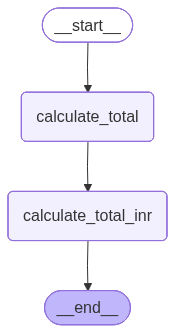

In [5]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
graph.invoke({"amount_usd": 100.0})

{'amount_usd': 100.0, 'total_usd': 108.0, 'total_inr': 8856.0}